# PASO 3 — Análisis Multivariante
## Proyecto: Análisis de Churn en TELCO

**Equipo:** Data & BI

**Objetivo de esta fase:** entender **qué variables están relacionadas con el
churn** antes de construir ningún modelo, y detectar **redundancias entre
variables** (multicolinealidad) que podrían perjudicar al modelo predictivo del
PASO 4.

Trabajamos sobre `data/cleaned/telco_cleaned.csv` (salida del PASO 2) y seguimos
la estructura del documento de requisitos:

1. **Correlación de Pearson** entre variables numéricas.
2. **VIF (Variance Inflation Factor)** para detectar multicolinealidad.
3. **Cramér's V** para la asociación entre variables categóricas y el churn.

Todas las figuras se guardan en `docs/analisis_multivariante/` para su uso
posterior en la documentación y en Power BI. Al final respondemos las **5
preguntas de reflexión** del documento.

## 0. Configuración inicial

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from statsmodels.stats.outliers_influence import variance_inflation_factor
import os
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 250)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

# sns.set_theme para cambiar el estilo de los gráficos, 
# concretamente para que tengan fondo blanco y cuadrícula
sns.set_theme(style='whitegrid')

CLEANED_PATH = '../data/cleaned/telco_cleaned.csv'
OUT_DIR = '../docs/analisis_multivariante/'
os.makedirs(OUT_DIR, exist_ok=True)

df = pd.read_csv(CLEANED_PATH)
print("Shape:", df.shape)

# Variable derivada de apoyo (no se anade al CSV, solo para este analisis):
# flag San Diego, para contrastar la hipotesis 2 de Sebastian
df['es_san_diego'] = np.where(df['city'] == 'San Diego', 'Yes', 'No')

global_churn = df['churn_value'].mean()
print(f"Tasa de churn global: {global_churn:.2%}")

Shape: (7043, 48)
Tasa de churn global: 26.54%


## 1. Análisis de correlación — variables numéricas (Pearson)

### ¿Por qué utilizamos el coeficiente de correlación de Pearson en ciencia de datos?

El coeficiente de Pearson mide **la fuerza y la dirección de la relación lineal**
entre dos variables numéricas, en un rango de **-1 a 1**:

- **+1**: relación lineal positiva perfecta (cuando una sube, la otra sube en la
  misma proporción).
- **-1**: relación lineal negativa perfecta.
- **0**: no hay relación lineal (puede haber otro tipo de relación, ver la nota más
  abajo).

Es el punto de partida estándar en ciencia de datos porque: (1) es **fácil de
calcular e interpretar** — un solo número resume la relación entre dos variables;
(2) es la base de muchas técnicas posteriores (regresión lineal, PCA, selección de
variables); y (3) nos permite construir rápidamente una **matriz de correlación**
que resume, de un vistazo, las relaciones entre decenas de variables a la vez.

In [ ]:
# Variables numericas candidatas (excluimos identificadores como zip_code)
numeric_cols = ['age', 'number_of_dependents', 'number_of_referrals', 'tenure_in_months',
                'antiguedad_anios', 'avg_monthly_long_distance_charges', 'avg_monthly_gb_download',
                'monthly_charge', 'total_charges', 'total_refunds', 'total_extra_data_charges',
                'total_long_distance_charges', 'total_revenue', 'population', 'latitude', 'longitude']

# .corr method='pearson' calcula la correlación de Pearson entre las variables numéricas y churn_value
corr_matrix = df[numeric_cols + ['churn_value']].corr(method='pearson')
corr_matrix.round(2)

,age,number_of_dependents,number_of_referrals,tenure_in_months,antiguedad_anios,avg_monthly_long_distance_charges,avg_monthly_gb_download,monthly_charge,total_charges,total_refunds,total_extra_data_charges,total_long_distance_charges,total_revenue,population,latitude,longitude,churn_value
age,1.000,-0.100,-0.030,0.020,0.020,-0.010,-0.340,0.130,0.060,0.030,0.030,0.000,0.050,-0.010,-0.010,0.010,0.100
number_of_dependents,-0.100,1.000,0.280,0.110,0.110,-0.010,0.130,-0.130,0.020,0.010,-0.010,0.070,0.040,-0.020,0.030,-0.020,-0.220
number_of_referrals,-0.030,0.280,1.000,0.330,0.330,0.010,0.040,0.030,0.250,0.020,0.000,0.220,0.260,-0.010,0.020,-0.010,-0.290
tenure_in_months,0.020,0.110,0.330,1.000,1.000,0.010,0.050,0.240,0.830,0.060,0.080,0.670,0.850,-0.010,0.010,-0.010,-0.350
antiguedad_anios,0.020,0.110,0.330,1.000,1.000,0.010,0.050,0.240,0.830,0.060,0.080,0.670,0.850,-0.010,0.010,-0.010,-0.350
avg_monthly_long_distance_charges,-0.010,-0.010,0.010,0.010,0.010,1.000,-0.030,0.130,0.070,-0.020,0.000,0.600,0.230,-0.020,0.000,-0.000,0.010
avg_monthly_gb_download,-0.340,0.130,0.040,0.050,0.050,-0.030,1.000,0.380,0.220,0.000,0.090,0.010,0.180,0.020,-0.030,0.030,0.050
monthly_charge,0.130,-0.130,0.030,0.240,0.240,0.130,0.380,1.000,0.630,0.030,0.120,0.240,0.570,0.010,-0.020,0.020,0.190
total_charges,0.060,0.020,0.250,0.830,0.830,0.070,0.220,0.630,1.000,0.040,0.120,0.610,0.970,-0.010,-0.000,0.000,-0.200
total_refunds,0.030,0.010,0.020,0.060,0.060,-0.020,0.000,0.030,0.040,1.000,0.020,0.030,0.040,0.020,-0.010,-0.000,-0.030


**Decisión:** dejamos fuera del análisis numérico `zip_code` (es un identificador
geográfico, no una cantidad — decisión ya documentada en el PASO 2) y
`customer_id`. Incluimos `latitude`/`longitude` para comprobar si hay alguna
relación lineal directa con el churn, aunque por su naturaleza (coordenadas) no
esperamos que sea muy informativa por sí sola.

### Heatmap de correlaciones

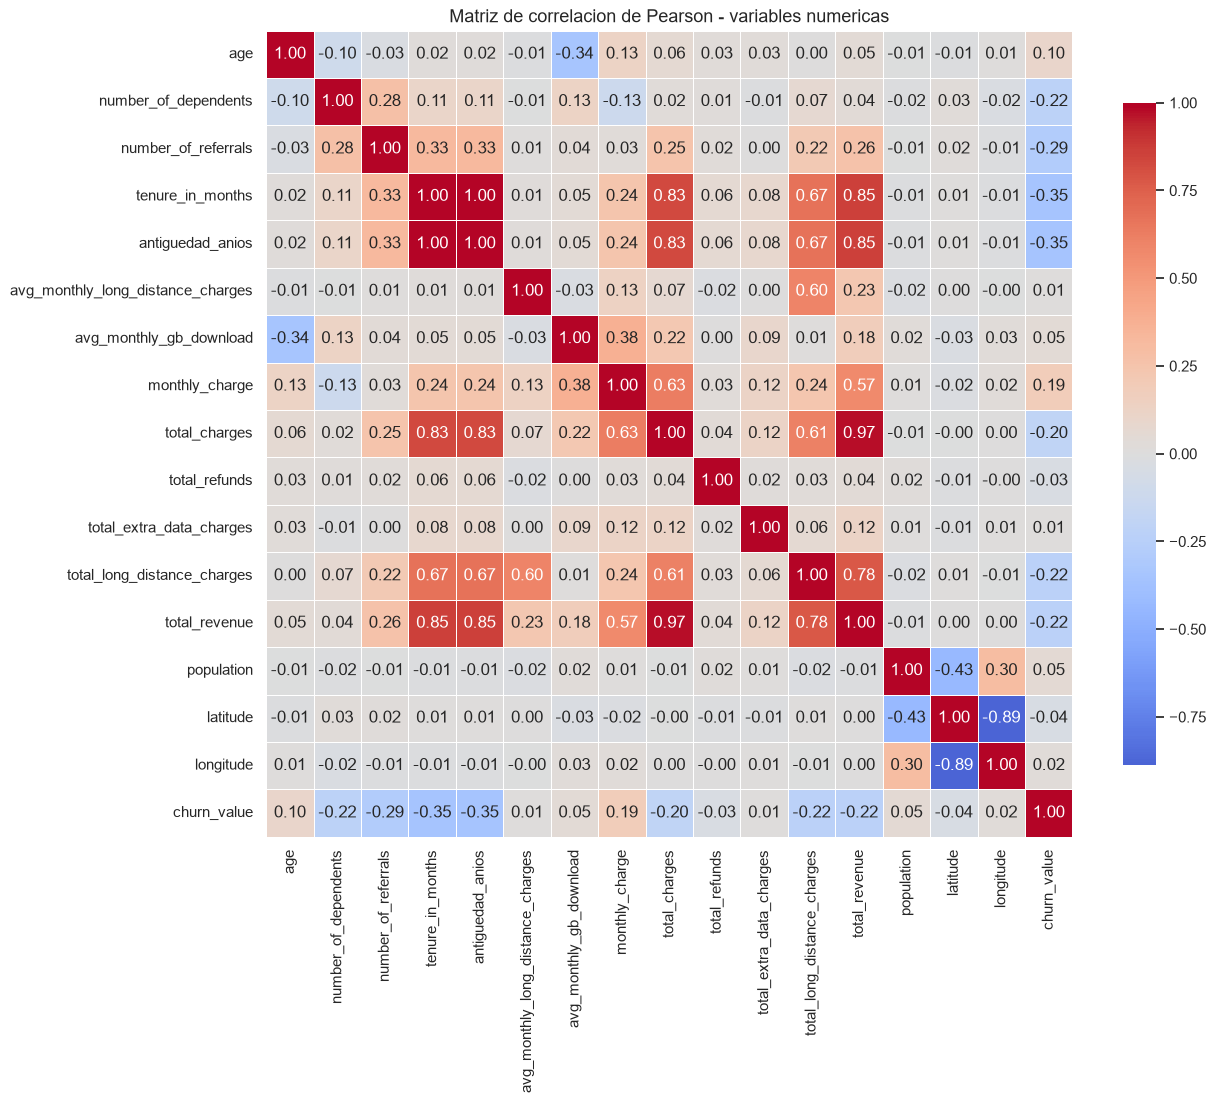

In [4]:
fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('Matriz de correlacion de Pearson - variables numericas', fontsize=13)
plt.tight_layout()
plt.savefig(OUT_DIR + 'heatmap_correlaciones.png', dpi=110, bbox_inches='tight')
plt.show()

### Correlación con `churn_value`

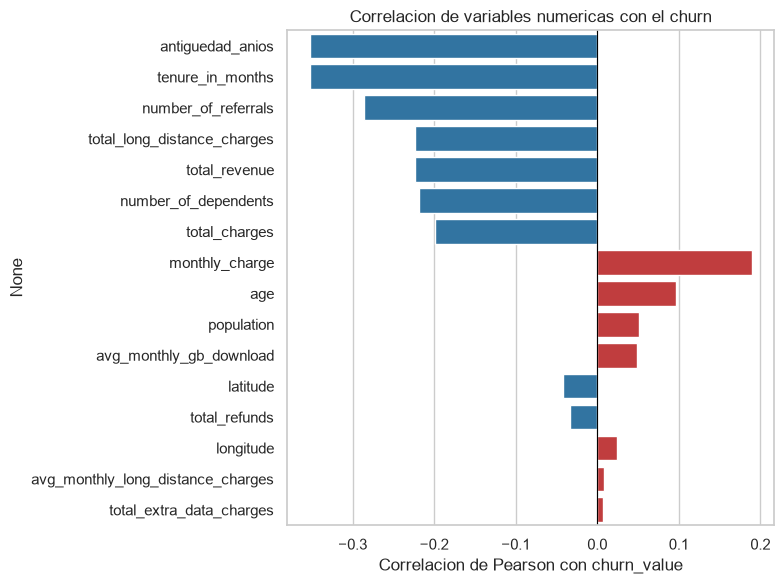

antiguedad_anios                    -0.353
tenure_in_months                    -0.353
number_of_referrals                 -0.287
total_long_distance_charges         -0.224
total_revenue                       -0.223
number_of_dependents                -0.219
total_charges                       -0.199
monthly_charge                       0.190
age                                  0.096
population                           0.052
avg_monthly_gb_download              0.049
latitude                            -0.042
total_refunds                       -0.034
longitude                            0.024
avg_monthly_long_distance_charges    0.008
total_extra_data_charges             0.007
Name: churn_value, dtype: float64

In [5]:
corr_churn = corr_matrix['churn_value'].drop('churn_value').sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#d62728' if v > 0 else '#1f77b4' for v in corr_churn.values]
sns.barplot(x=corr_churn.values, y=corr_churn.index, hue=corr_churn.index,
            palette=colors, legend=False, ax=ax)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Correlacion de Pearson con churn_value')
ax.set_title('Correlacion de variables numericas con el churn')
plt.tight_layout()
plt.savefig(OUT_DIR + 'correlacion_churn.png', dpi=110, bbox_inches='tight')
plt.show()

corr_churn

**¿Qué variables tienen mayor correlación (positiva o negativa) con `churn_value`?**

Ordenando por valor absoluto, las más relevantes son:

| Variable | Correlación con `churn_value` |
|---|---|
| `tenure_in_months` / `antiguedad_anios` | **-0,353** (idénticas, ver más abajo) |
| `number_of_referrals` | -0,287 |
| `total_long_distance_charges` | -0,224 |
| `total_revenue` | -0,223 |
| `number_of_dependents` | -0,219 |
| `total_charges` | -0,199 |
| `monthly_charge` | **+0,190** |

El resto de variables (`age`, `population`, `avg_monthly_gb_download`,
`latitude`/`longitude`, `total_refunds`, `avg_monthly_long_distance_charges`,
`total_extra_data_charges`) tienen correlaciones por debajo de 0,1 en valor
absoluto — relación lineal prácticamente nula con el churn.

**¿Hay pares de variables muy correlacionadas entre sí? ¿Qué implica eso?**

Sí, varios pares destacan claramente en el heatmap:

| Par de variables | Correlación |
|---|---|
| `tenure_in_months` ↔ `antiguedad_anios` | **1.00** (perfecta) |
| `total_charges` ↔ `total_revenue` | 0.97 |
| `latitude` ↔ `longitude` | -0.89 |
| `tenure_in_months` ↔ `total_revenue` | 0.85 |
| `tenure_in_months` ↔ `total_charges` | 0.83 |
| `total_long_distance_charges` ↔ `total_revenue` | 0.78 |
| `monthly_charge` ↔ `total_charges` | 0.63 |

Esto implica que estas variables **no aportan información independiente**: dos
variables con correlación 1.00 son matemáticamente la misma información en otra
escala (`antiguedad_anios = tenure_in_months / 12`), y `total_revenue` es —como ya
vimos en el PASO 2— una combinación lineal exacta de `total_charges`,
`total_refunds`, `total_extra_data_charges` y `total_long_distance_charges`. Si
metiéramos todas estas variables en un modelo lineal sin tratarlas, estaríamos
introduciendo **multicolinealidad severa** — lo cuantificamos formalmente con el
VIF en la siguiente sección.

### Completando con visualizaciones (la correlación de Pearson solo detecta relaciones lineales)

> *"La correlación de Pearson mide relaciones lineales. Si una relación no es
> lineal, puede que no la detectes aquí. Complétala con visualizaciones."*

Por eso, para las variables numéricas con mayor correlación, dibujamos también su
**distribución por grupo de churn** (boxplots). Un boxplot puede revelar
diferencias entre grupos (medianas, dispersión, outliers) que un único coeficiente
de correlación no captura del todo, especialmente si la relación no es estrictamente
lineal.

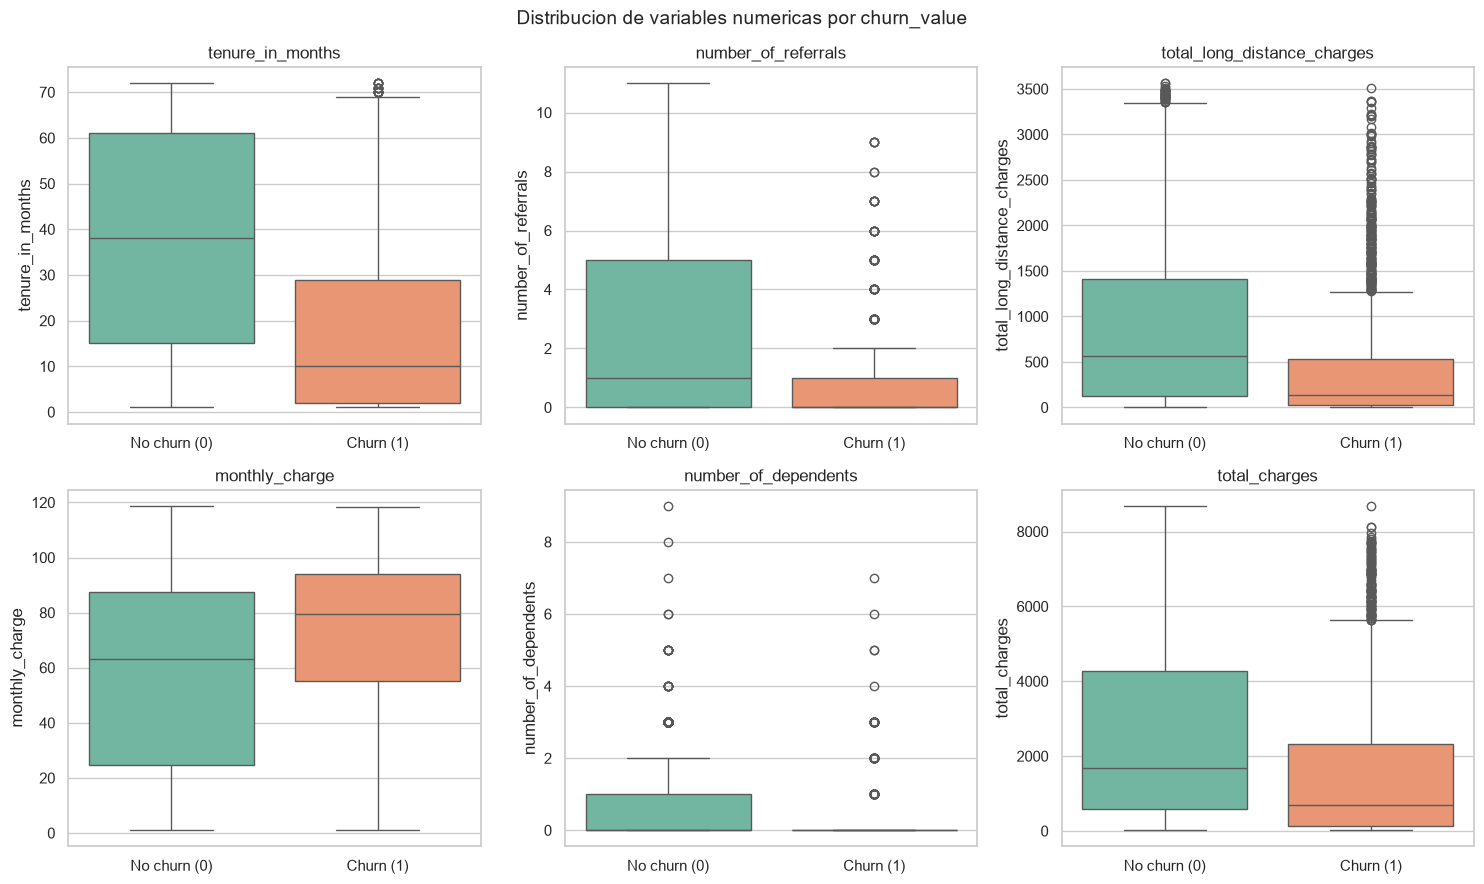

In [6]:
vars_boxplot = ['tenure_in_months', 'number_of_referrals', 'total_long_distance_charges',
                'monthly_charge', 'number_of_dependents', 'total_charges']

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, var in zip(axes.flat, vars_boxplot):
    sns.boxplot(data=df, x='churn_value', y=var, hue='churn_value', palette='Set2',
                legend=False, ax=ax)
    ax.set_xticklabels(['No churn (0)', 'Churn (1)'])
    ax.set_title(var)
    ax.set_xlabel('')

fig.suptitle('Distribucion de variables numericas por churn_value', fontsize=14)
plt.tight_layout()
plt.savefig(OUT_DIR + 'distribuciones_numericas_por_churn.png', dpi=110, bbox_inches='tight')
plt.show()

**Lectura de los boxplots:**

- `tenure_in_months`: la mediana de los clientes que hacen churn es claramente más
  baja — confirma visualmente la correlación negativa, y muestra que el efecto es
  consistente en toda la distribución, no solo "en promedio".
- `number_of_referrals`: la mayoría de clientes que hacen churn tienen **0
  referidos** (mediana = 0 con caja muy comprimida), mientras que los que se
  quedan tienen más variedad — sugiere que "tener referidos" (estar conectado al
  servicio a través de otras personas) es protector frente al churn.
- `total_long_distance_charges`, `total_charges`: medianas más bajas en el grupo de
  churn, coherente con su correlación negativa (clientes que se van llevan menos
  tiempo acumulando cargos).
- `monthly_charge`: la mediana es ligeramente más alta en el grupo de churn,
  coherente con la correlación positiva débil.
- `number_of_dependents`: los clientes que hacen churn tienen casi siempre **0
  dependientes** — refuerza la señal de Cramér's V que veremos más adelante para
  `dependents`.

No detectamos ninguna relación claramente **no lineal** (en forma de "U" o
similar) que la correlación de Pearson estuviera ocultando — las relaciones que
existen parecen, en su mayoría, monótonas.

## 2. Análisis de multicolinealidad — VIF

### ¿Qué nos indica el VIF en análisis de datos?

El **VIF (Variance Inflation Factor)** cuantifica cuánto se "infla" la varianza del
coeficiente estimado para una variable, debido a su correlación con las **demás**
variables predictoras. Concretamente, `VIF = 1 / (1 - R²)`, donde `R²` es el
resultado de regresar esa variable contra todas las demás. Un `VIF` alto significa
que esa variable es **(casi) explicable a partir de las otras** — es decir, aporta
poca información "propia" adicional al conjunto.

### Primera pasada — dataset numérico completo

In [7]:
def calcular_vif(data, columnas):
    X_vif = data[columnas].dropna()
    vif_df = pd.DataFrame()
    vif_df['variable'] = X_vif.columns
    vif_df['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
    return vif_df.sort_values('VIF', ascending=False).reset_index(drop=True)

vif_v1 = calcular_vif(df, numeric_cols)
vif_v1

,variable,VIF
0,total_long_distance_charges,inf
1,total_extra_data_charges,inf
2,total_refunds,inf
3,total_revenue,inf
4,total_charges,inf
5,tenure_in_months,"1,570,178.964"
6,antiguedad_anios,"1,569,441.172"
7,longitude,530.834
8,latitude,465.114
9,monthly_charge,16.767


**Interpretación de la primera pasada:**

Cinco variables muestran **VIF = infinito**: `total_charges`, `total_refunds`,
`total_extra_data_charges`, `total_long_distance_charges` y `total_revenue`. Esto
ocurre porque `total_revenue` es **exactamente** una combinación lineal de las
otras cuatro (lo descubrimos en el PASO 2) — la matriz de estas 5 columnas es
**singular** (rango deficiente), por lo que `R² = 1` y `VIF = 1/(1-1) = ∞`.

Además, `tenure_in_months` y `antiguedad_anios` tienen un VIF de **≈ 1.570.000**
— en la práctica, también "infinito": son la misma variable en dos unidades
distintas (`antiguedad_anios = tenure_in_months / 12`), así que cada una se explica
perfectamente a partir de la otra.

**Decisión:** eliminamos `antiguedad_anios` (nos quedamos con `tenure_in_months`,
la unidad original y más granular) y `total_revenue` (nos quedamos con sus 4
componentes — `total_charges`, `total_refunds`, `total_extra_data_charges`,
`total_long_distance_charges` — que aportan información más detallada de forma
individual). Recalculamos el VIF.

In [8]:
numeric_cols_v2 = [c for c in numeric_cols if c not in ['antiguedad_anios', 'total_revenue']]
vif_v2 = calcular_vif(df, numeric_cols_v2)
vif_v2

,variable,VIF
0,longitude,530.743
1,latitude,465.114
2,tenure_in_months,19.233
3,total_charges,16.962
4,monthly_charge,16.747
5,age,9.599
6,total_long_distance_charges,9.185
7,avg_monthly_long_distance_charges,9.060
8,avg_monthly_gb_download,3.034
9,population,2.669


**Interpretación de la segunda pasada:**

Los `VIF = inf` han desaparecido, pero `latitude` (≈ 465) y `longitude` (≈ 531)
siguen mostrando valores **extremadamente altos** — coherente con la correlación
de -0,89 que vimos entre ambas (la forma alargada de California en diagonal
NO-SE hace que latitud y longitud estén muy ligadas entre sí).

Sin embargo, ambas tienen una correlación con `churn_value` prácticamente nula
(-0,04 y 0,02). Es decir: **aportan mucho "ruido redundante" entre sí, y casi
ninguna señal sobre el churn**. La información geográfica relevante para el
negocio (p. ej. el efecto de San Diego) ya está disponible de forma más
interpretable a través de `city`, `zip_code` y `population`.

**Decisión:** eliminamos `latitude` y `longitude` del conjunto de variables para
el análisis multivariante / modelado (se conservan en `telco_cleaned.csv` para
las visualizaciones de mapas en Power BI, pero no se usarán como *features*
numéricas). Recalculamos el VIF una última vez.

In [9]:
numeric_cols_v3 = [c for c in numeric_cols_v2 if c not in ['latitude', 'longitude']]
vif_v3 = calcular_vif(df, numeric_cols_v3)
vif_v3

,variable,VIF
0,monthly_charge,14.020
1,total_charges,13.513
2,tenure_in_months,12.328
3,total_long_distance_charges,8.278
4,avg_monthly_long_distance_charges,7.426
5,age,6.709
6,avg_monthly_gb_download,2.772
7,population,2.012
8,number_of_referrals,1.707
9,number_of_dependents,1.415


### ¿Entre qué rangos consideraríamos una multicolinealidad severa (para este caso de negocio)?

Usamos la siguiente escala, habitual en la práctica y razonable para este
proyecto:

| Rango de VIF | Interpretación |
|---|---|
| `VIF < 5` | Sin problema relevante. |
| `5 ≤ VIF < 10` | Moderada — vigilar, normalmente aceptable. |
| `10 ≤ VIF < 30` | Alta — la variable comparte mucha información con otras; revisar si es redundante. |
| `VIF ≥ 30` (o `inf`) | **Severa** — dependencia (casi) exacta con otra(s) variable(s); eliminar una de ellas es casi obligatorio. |

Con esta escala:

- `total_charges`, `total_refunds`, `total_extra_data_charges`,
  `total_long_distance_charges`, `total_revenue`, `tenure_in_months` y
  `antiguedad_anios` mostraban inicialmente VIF **severos (`inf` o ~1,5 millones)**
  → tratados eliminando `antiguedad_anios` y `total_revenue`.
- `latitude` y `longitude` mostraban VIF **severos (~465-531)** → eliminadas del
  conjunto de modelado.
- En la versión final (`numeric_cols_v3`), el VIF máximo es **≈ 14** (
  `monthly_charge`), seguido de `total_charges` (≈ 13,5) y `tenure_in_months`
  (≈ 12,3) — están en la zona **"alta pero no severa"**. Tiene sentido de
  negocio: `total_charges ≈ monthly_charge × tenure_in_months`, así que es
  esperable que estén relacionadas entre sí.

### Cuando hay multicolinealidad alta, ¿qué variable de un par redundante eliminarías y por qué?

En general, ante un par muy correlacionado, eliminamos la variable que sea:

1. **Menos granular / más derivada** (p. ej. `antiguedad_anios` frente a
   `tenure_in_months`, que es la unidad "fuente").
2. **Una combinación de otras** (p. ej. `total_revenue`, que es la suma/resta de
   otras 4 columnas — eliminamos el agregado y nos quedamos con los componentes).
3. **La que aporte menos señal sobre el churn** cuando ambas son conceptualmente
   intercambiables (p. ej. entre `latitude`/`longitude` y la información
   geográfica categórica ya disponible en `city`/`population`, nos quedamos con
   estas últimas).

Para `monthly_charge`, `total_charges` y `tenure_in_months` (VIF 12-14, "alto" pero
no "severo"), **no eliminamos ninguna**: las tres tienen relevancia de negocio
directa y correlación no despreciable con el churn. Para la **Regresión Logística**
(PASO 4) seremos cautos al interpretar sus coeficientes individuales (pueden ser
inestables), pero **Random Forest y Gradient Boosting son robustos a este nivel de
multicolinealidad** (según el glosario del proyecto), por lo que las
predicciones globales no se verán comprometidas.

**Conjunto final de variables numéricas para el PASO 4 / PASO 5**
(`numeric_cols_v3`, 12 variables):

In [10]:
print(numeric_cols_v3)

['age', 'number_of_dependents', 'number_of_referrals', 'tenure_in_months', 'avg_monthly_long_distance_charges', 'avg_monthly_gb_download', 'monthly_charge', 'total_charges', 'total_refunds', 'total_extra_data_charges', 'total_long_distance_charges', 'population']


## 3. Asociación con el churn — variables categóricas (Cramér's V)

La correlación de Pearson no aplica a variables categóricas. Usamos **Cramér's V**,
que mide la asociación entre dos variables categóricas a partir del estadístico
chi-cuadrado de su tabla de contingencia, en un rango de **0 (sin asociación) a 1
(asociación perfecta)**.

In [ ]:
def cramers_v(x, y):
    # Construye la tabla de contingencia entre las dos variables
    contingency_table = pd.crosstab(x, y)
    # Extrae el chi2 de la prueba de independencia
    chi2 = chi2_contingency(contingency_table)[0]
    # n = total de observaciones; r, k = dimensiones de la tabla
    n = contingency_table.sum().sum()
    r, k = contingency_table.shape
    return np.sqrt(chi2 / (n * (min(k - 1, r - 1))))


cat_vars = ['gender', 'under_30', 'senior_citizen', 'married', 'dependents', 'grupo_edad',
            'referred_a_friend', 'offer', 'phone_service', 'multiple_lines', 'internet_service',
            'internet_type', 'online_security', 'online_backup', 'device_protection_plan',
            'premium_tech_support', 'streaming_tv', 'streaming_movies', 'streaming_music',
            'unlimited_data', 'contract', 'paperless_billing', 'payment_method', 'es_san_diego',
            'customer_status', 'churn_label', 'churn_category', 'churn_reason']

resultados = []
for var in cat_vars:
    
    # cramers_v calcula la fuerza de asociación entre dos variables categóricas
    v = cramers_v(df[var], df['churn_value']) 

    # Las variables leakage son aquellas que contienen información del churn (post-churn) 
    # y no deberían ser utilizadas como predictoras en un modelo de predicción de churn. 
    # Por eso, se etiquetan como 'Leakage (post-churn)' si pertenecen a la lista de variables de leakage, 
    # y como 'Predictora' en caso contrario.
    es_leakage = var in ['customer_status', 'churn_label', 'churn_category', 'churn_reason']
    resultados.append((var, v, 'Leakage (post-churn)' if es_leakage else 'Predictora'))

cramers_df = pd.DataFrame(resultados, columns=['variable', 'cramers_v', 'tipo']).sort_values('cramers_v', ascending=False)
cramers_df.reset_index(drop=True)

,variable,cramers_v,tipo
0,churn_reason,1.000,Leakage (post-churn)
1,customer_status,1.000,Leakage (post-churn)
2,churn_category,1.000,Leakage (post-churn)
3,churn_label,1.000,Leakage (post-churn)
4,contract,0.453,Predictora
5,internet_type,0.305,Predictora
6,offer,0.262,Predictora
7,dependents,0.248,Predictora
8,internet_service,0.228,Predictora
9,payment_method,0.219,Predictora


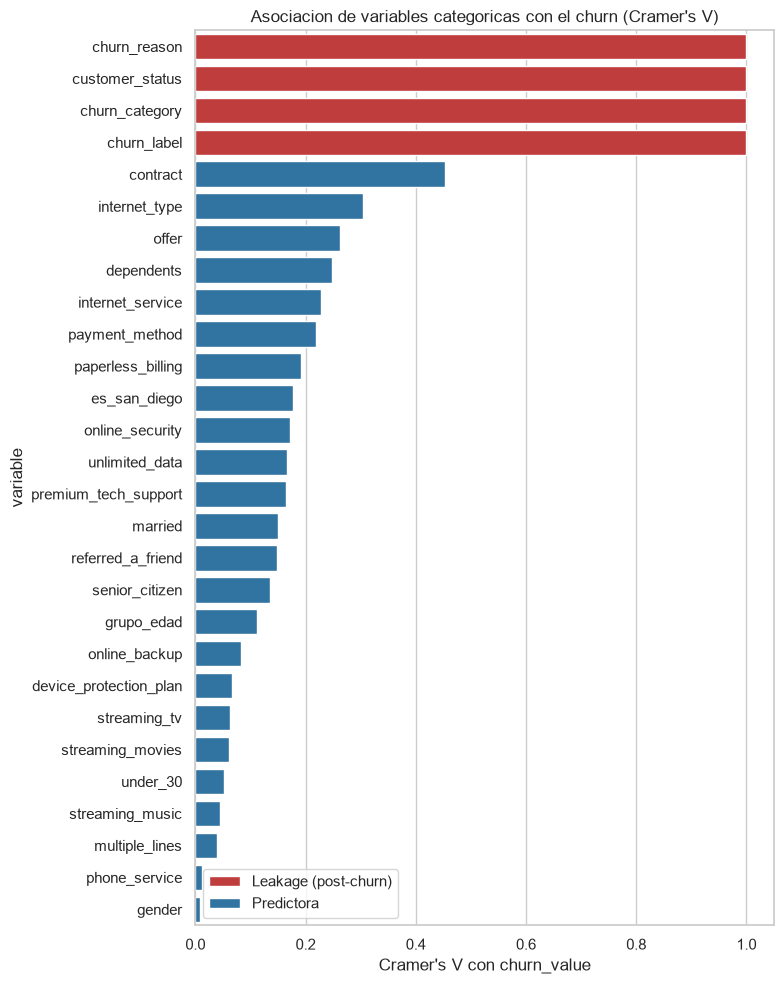

In [12]:
fig, ax = plt.subplots(figsize=(8, 10))
palette = {'Predictora': '#1f77b4', 'Leakage (post-churn)': '#d62728'}
sns.barplot(data=cramers_df, x='cramers_v', y='variable', hue='tipo', dodge=False,
            palette=palette, ax=ax)
ax.set_xlabel("Cramer's V con churn_value")
ax.set_title("Asociacion de variables categoricas con el churn (Cramer's V)")
ax.legend(title='')
plt.tight_layout()
plt.savefig(OUT_DIR + 'cramers_v_categoricas.png', dpi=110, bbox_inches='tight')
plt.show()

**¿Qué variables categóricas tienen mayor asociación con el churn?**

Separando las variables **predictoras** de las de **leakage** (en rojo —
`customer_status`, `churn_label`, `churn_category`, `churn_reason`, todas con
Cramér's V = 1.00 porque son el target en otra forma, lo discutimos en la pregunta
de reflexión 4):

| Variable | Cramér's V | Comentario |
|---|---|---|
| `contract` | **0,453** | La más asociada de todas las predictoras. |
| `internet_type` | 0,305 | |
| `offer` | 0,262 | |
| `dependents` | 0,248 | |
| `internet_service` | 0,228 | (redundante con `internet_type`) |
| `payment_method` | 0,219 | |
| `paperless_billing` | 0,191 | |
| `es_san_diego` | 0,178 | Variable creada para esta sección — contrasta la hipótesis 2 de Sebastián. |
| `online_security` | 0,171 | |
| ... | ... | el resto < 0,17 |

**Nota sobre `city`:** si calculamos Cramér's V directamente sobre `city` (1.106
categorías) obtenemos un valor de 0,443 — similar al de `contract` — pero hay que
interpretarlo con cautela: con tantas categorías y muestras pequeñas en muchas
ciudades, el estadístico chi-cuadrado tiende a inflarse por azar (ciudades con 1-2
clientes que "casualmente" todos churnean o ninguno). Por eso construimos el flag
binario `es_san_diego`, mucho más interpretable y directamente vinculado a la
hipótesis de negocio.

### Countplots y tasa de churn por variable

A continuación generamos, **para todas las variables categóricas** (excepto
`churn_reason`, por su altísima cardinalidad), dos gráficos:

- **Countplot**: cuántos clientes hay en cada categoría.
- **Tasa de churn**: la tasa de churn dentro de cada categoría, con una línea
  discontinua marcando la tasa global (26,5%).

Todos los gráficos se guardan en `docs/analisis_multivariante/` (con los nombres
`{variable}_countplot.png` y `{variable}_churn_rate.png`). Para mantener el
notebook legible, **solo mostramos aquí las variables más relevantes** según
Cramér's V y según las hipótesis de Sebastián; el resto quedan guardadas como
archivo para la documentación y el dashboard.

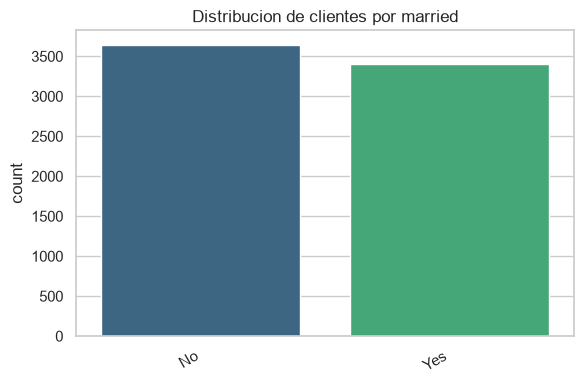

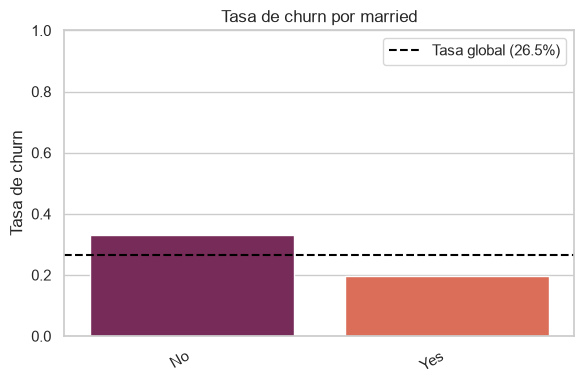

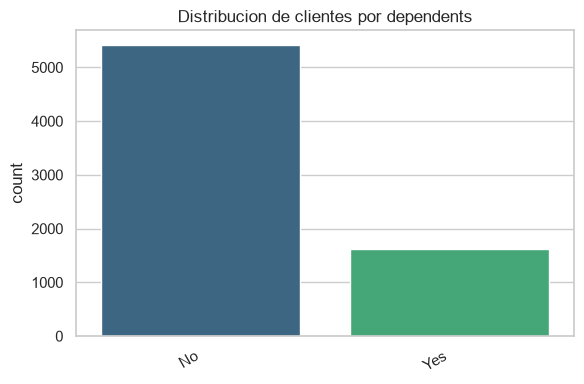

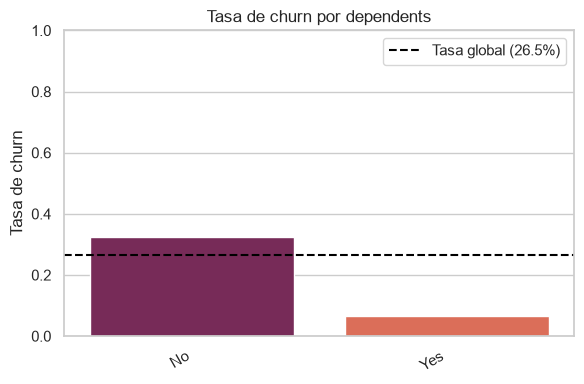

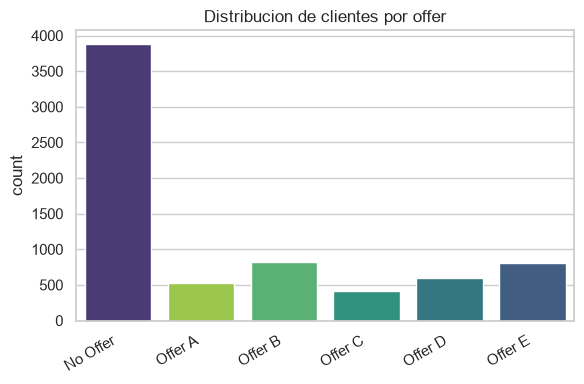

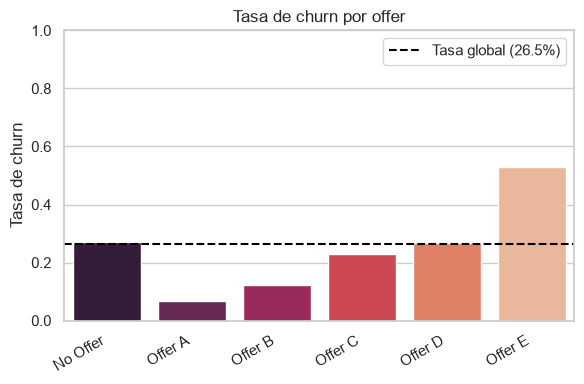

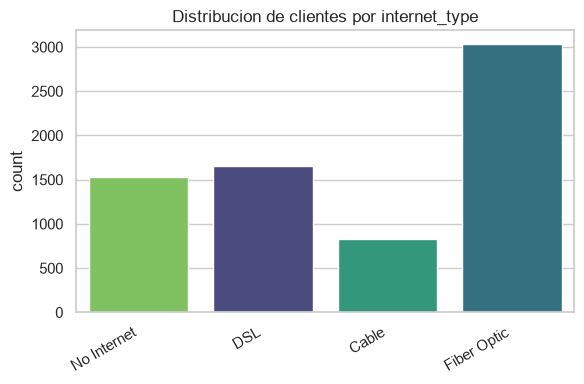

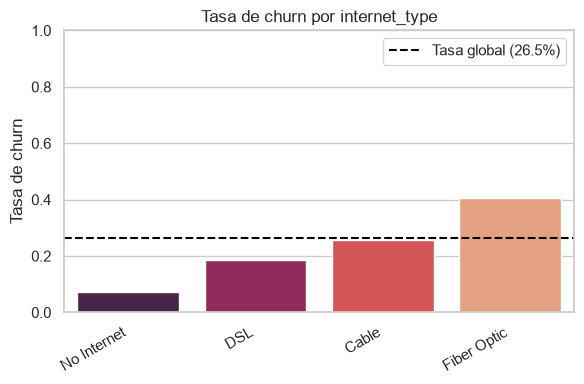

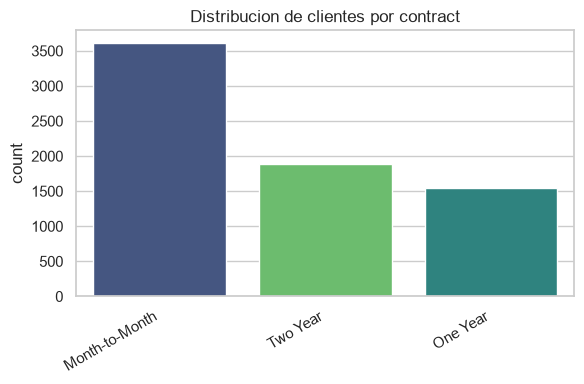

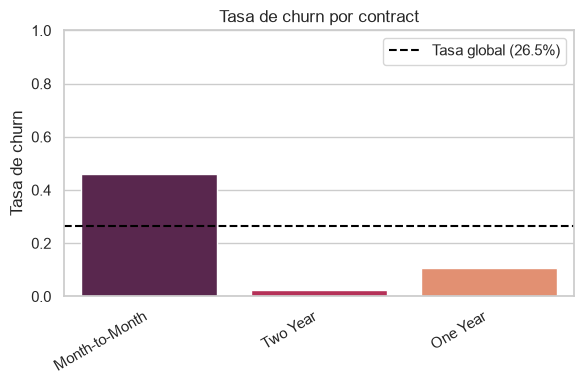

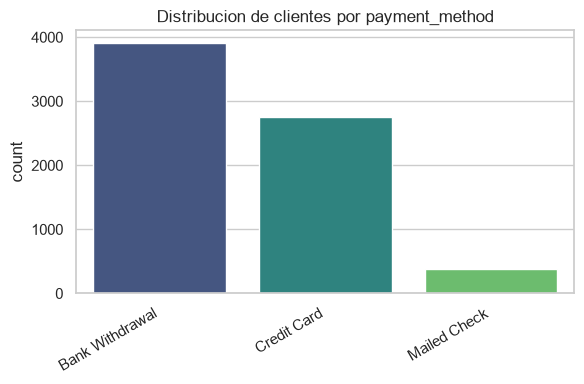

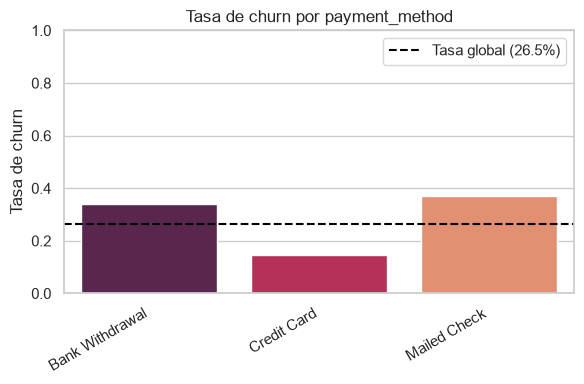

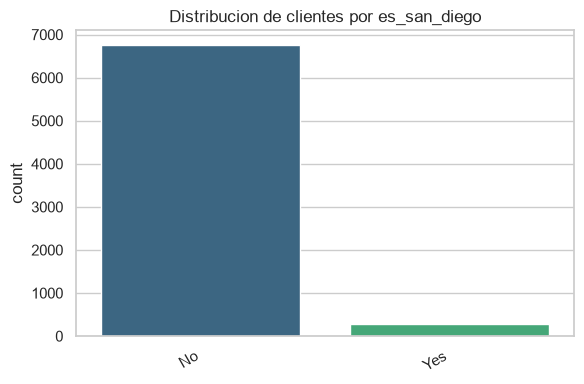

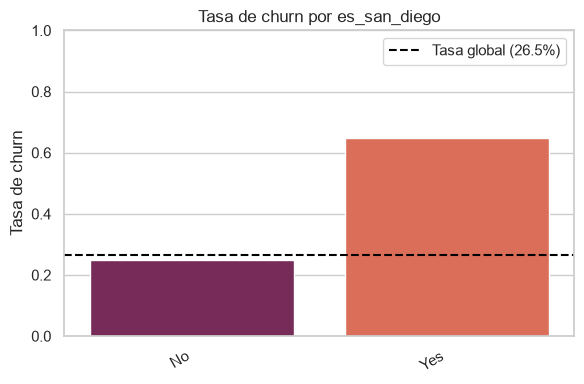

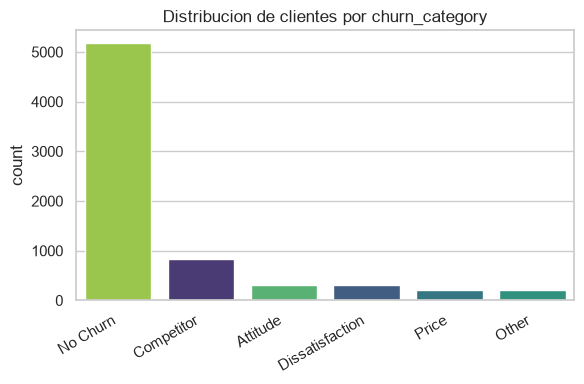

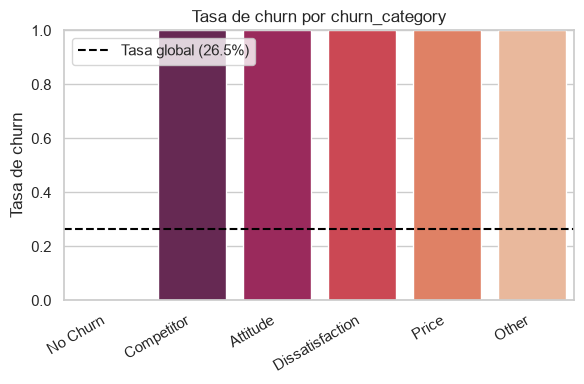

Generados 54 graficos en ../docs/analisis_multivariante/


In [13]:
# Orden personalizado para variables con un orden logico natural
custom_order = {
    'grupo_edad': ['<30', '30-44', '45-59', '60+'],
    'offer': ['No Offer', 'Offer A', 'Offer B', 'Offer C', 'Offer D', 'Offer E'],
    'internet_type': ['No Internet', 'DSL', 'Cable', 'Fiber Optic'],
}

# Variables que SI se muestran en el notebook (las mas relevantes)
mostrar_inline = ['contract', 'internet_type', 'offer', 'dependents', 'payment_method',
                   'es_san_diego', 'married', 'churn_category']

plot_vars = [v for v in cat_vars if v != 'churn_reason']

for var in plot_vars:
    order = custom_order.get(var, df[var].value_counts().index.tolist())

    # Countplot
    fig1, ax1 = plt.subplots(figsize=(6, 4))
    sns.countplot(data=df, x=var, order=order, hue=var, palette='viridis', legend=False, ax=ax1)
    ax1.set_title(f'Distribucion de clientes por {var}')
    ax1.set_xlabel('')
    ax1.tick_params(axis='x', rotation=30)
    for label in ax1.get_xticklabels():
        label.set_horizontalalignment('right')
    plt.tight_layout()
    fig1.savefig(OUT_DIR + f'{var}_countplot.png', dpi=110, bbox_inches='tight')

    # Tasa de churn
    fig2, ax2 = plt.subplots(figsize=(6, 4))
    rates = df.groupby(var)['churn_value'].mean().reindex(order)
    sns.barplot(x=rates.index, y=rates.values, hue=rates.index, palette='rocket',
                legend=False, ax=ax2)
    ax2.axhline(global_churn, color='black', linestyle='--',
                label=f'Tasa global ({global_churn:.1%})')
    ax2.set_ylabel('Tasa de churn')
    ax2.set_xlabel('')
    ax2.set_title(f'Tasa de churn por {var}')
    ax2.set_ylim(0, 1)
    ax2.tick_params(axis='x', rotation=30)
    for label in ax2.get_xticklabels():
        label.set_horizontalalignment('right')
    ax2.legend()
    plt.tight_layout()
    fig2.savefig(OUT_DIR + f'{var}_churn_rate.png', dpi=110, bbox_inches='tight')

    if var in mostrar_inline:
        plt.show()
    else:
        plt.close(fig1)
        plt.close(fig2)

print(f"Generados {len(plot_vars)*2} graficos en {OUT_DIR}")

**Lectura de las variables mostradas:**

- **`contract`**: tasa de churn 45,8% (Month-to-Month) vs 10,7% (One Year) vs 2,5%
  (Two Year) — la diferencia más marcada entre las variables predictoras, y
  **confirma la hipótesis 1 de Sebastián**: los contratos mes-a-mes son, con
  diferencia, los más asociados al churn.
- **`internet_type`**: Fiber Optic destaca con 40,7% de churn frente a 25,7%
  (Cable), 18,6% (DSL) y solo 7,4% en clientes sin internet. Posible explicación:
  Fiber Optic es el servicio más caro/competido, y donde la competencia (cable,
  otros operadores de fibra) es más agresiva.
- **`offer`**: `Offer E` tiene una tasa de churn del 52,9% — la más alta de todas
  las categorías analizadas, muy por encima incluso de "sin oferta" (27,1%).
  Esto podría indicar que `Offer E` se ofrece **a clientes que ya estaban en
  riesgo** (oferta de retención que no funciona), o que la oferta en sí es poco
  atractiva — sería interesante una reunión con el equipo comercial.
- **`dependents`**: clientes sin dependientes a cargo churnean un 32,6% frente a
  solo un 6,5% de los que sí tienen dependientes — consistente con el boxplot de
  `number_of_dependents` que vimos antes.
- **`payment_method`**: `Mailed Check` (36,9%) y `Bank Withdrawal` (34,0%) muestran
  tasas de churn muy superiores a `Credit Card` (14,5%) — el método de pago podría
  ser un proxy de "compromiso"/automatización con el servicio.
- **`es_san_diego`**: 64,9% de churn en San Diego frente a 24,9% en el resto de
  California — **confirma la hipótesis 2 de Sebastián**, y de forma muy contundente
  (más del doble que la media global).
- **`married`**: clientes solteros churnean más (33,0% vs 19,7%) — coherente con el
  patrón de `dependents`.
- **`churn_category`**: aquí el patrón es **perfecto** — `No Churn` tiene 0% de
  churn (por definición) y **todas** las demás categorías (`Competitor`,
  `Attitude`, `Dissatisfaction`, `Price`, `Other`) tienen 100% de churn. Esto es
  precisamente la señal de **data leakage** que tratamos en la pregunta de
  reflexión 4: una variable que "predice" el churn al 100% no es una variable
  predictiva, es **el propio target reformulado**.

## Preguntas de reflexión — Análisis Multivariante

### 1. ¿Qué variable numérica tiene la correlación más alta con el churn? ¿Tiene sentido desde el punto de vista del negocio?

La correlación más alta (en valor absoluto) es la de **`tenure_in_months`** (y su
gemela `antiguedad_anios`, idéntica salvo la escala), con **r ≈ -0,353**.

**Sí, tiene mucho sentido de negocio**: cuanto más tiempo lleva un cliente con
TELCO, menos probable es que se vaya. Los clientes nuevos están en una fase donde
todavía no han "construido el hábito" de usar el servicio, pueden estar probando
varias operadoras a la vez, y —si tienen un contrato mes-a-mes— no tienen ninguna
penalización por cambiarse. Es, junto con `contract`, la variable que articula la
narrativa central del proyecto: **la "lealtad" del cliente (medida en tiempo y en
tipo de contrato) es el factor más protector frente al churn**.

### 2. ¿Encontraste variables altamente correlacionadas entre sí? ¿Cuáles y qué harías con ellas de cara al modelado?

Sí, varios pares/grupos:

- **`tenure_in_months` ↔ `antiguedad_anios`** (r = 1,00): son la misma variable en
  distinta escala (meses vs años). **Acción**: eliminar `antiguedad_anios` del
  conjunto de modelado, conservar `tenure_in_months`.
- **`total_revenue` ↔ {`total_charges`, `total_refunds`, `total_extra_data_charges`,
  `total_long_distance_charges`}** (VIF = `inf`, porque `total_revenue` es su suma
  algebraica exacta). **Acción**: eliminar `total_revenue` del conjunto de
  modelado, conservar sus 4 componentes (más informativos individualmente).
- **`latitude` ↔ `longitude`** (r = -0,89, VIF ≈ 465-531): muy correlacionadas
  entre sí y casi sin relación con el churn. **Acción**: eliminar ambas del
  conjunto de modelado; la información geográfica relevante ya está en `city` y
  `population`, y se conservan en `telco_cleaned.csv` para mapas en Power BI.
- **`monthly_charge` ↔ `total_charges` ↔ `tenure_in_months`** (VIF entre 12 y 14,
  "alto" pero no "severo"): **Acción**: se mantienen las tres — son
  conceptualmente importantes y los modelos de árboles (Random Forest, Gradient
  Boosting) son robustos a este nivel de colinealidad. Para la Regresión Logística
  interpretaremos sus coeficientes individuales con cautela.

El conjunto final de variables numéricas para el PASO 4/5 queda en **12
variables** (`numeric_cols_v3`), todas con VIF ≤ ~14.

### 3. ¿Qué variable categórica está más asociada con el churn según Cramér's V? ¿Confirma o refuta las hipótesis de Sebastián?

Entre las variables **predictoras** (excluyendo las de leakage), la más asociada es
**`contract`** (Cramér's V = 0,453), muy por delante de la siguiente
(`internet_type`, 0,305).

Esto **confirma directamente la primera hipótesis de Sebastián** ("los contratos
mes-a-mes son la causa principal del churn"): es, con diferencia, la variable
categórica con mayor poder explicativo, y la tasa de churn de Month-to-Month
(45,8%) frente a Two Year (2,5%) es la diferencia más grande que hemos observado
en todo el análisis.

La segunda hipótesis ("San Diego es la región más afectada por la competencia")
también se **confirma**, aunque con un Cramér's V más moderado (`es_san_diego` =
0,178). Esto no contradice la magnitud del efecto — dentro de San Diego, la tasa de
churn (64,9%) es la más alta de cualquier segmento que hemos analizado — sino que
refleja que **San Diego es solo el 4% de la base de clientes** (285 de 7.043):
Cramér's V mide cuánto se reduce la incertidumbre sobre el churn **en el conjunto
de toda la población**, y un efecto extremo en un grupo pequeño tiene,
matemáticamente, menos impacto "global" que un efecto moderado en un grupo grande
(`contract`, que afecta a los 7.043 clientes). Para Sebastián, ambas cosas son
ciertas a la vez: *"el contrato mes-a-mes es el problema más extendido, pero San
Diego es el punto más caliente"*.

### 4. ¿Observas alguna variable que tenga alta correlación con el churn pero que podría ser un caso de data leakage? ¿Cómo lo identificas?

Sí: **`customer_status`, `churn_label`, `churn_category` y `churn_reason`** tienen
todas Cramér's V = **1,00** — asociación perfecta con `churn_value`.

**Cómo lo identificamos:**

1. **El valor en sí es la señal de alarma**: una asociación *perfecta* (1,00, o una
   correlación de Pearson cercana a ±1 en el caso numérico) casi nunca ocurre de
   forma natural en un problema de negocio real — cuando aparece, lo primero que
   hay que preguntarse es *"¿esta variable es, en realidad, el target con otro
   nombre?"*.
2. **La prueba conceptual del "momento en el tiempo"**: para cada variable,
   preguntamos *¿conoceríamos este valor en el momento de hacer la predicción
   (cuando el cliente todavía está activo), o solo lo sabemos DESPUÉS de que el
   cliente se haya ido?* `churn_reason` y `churn_category` solo existen **una vez
   que el cliente ya ha churneado** — para un cliente activo, su valor sería
   siempre `'No Churn'` por construcción, así que no aportarían ninguna señal real
   en producción, solo "memorizarían" la respuesta durante el entrenamiento.
   `customer_status = 'Churned'` es, literalmente, la definición de
   `churn_value = 1`. `churn_label` es la misma variable que `churn_value` en
   formato texto.

Estas 4 columnas se **mantienen en `telco_cleaned.csv`** (las necesitamos para este
mismo análisis y para el dashboard del PASO 6), pero se **eliminarán
explícitamente del conjunto `X` de variables predictoras** en el PASO 4, justo
antes de entrenar cualquier modelo.

### 5. ¿Qué conclusiones preliminares puedes extraer sobre los factores que impulsan el churn en TELCO?

A falta del modelo predictivo (PASO 4), el análisis multivariante ya dibuja una
historia bastante clara:

- **El "factor contrato" es el más importante**: los contratos mes-a-mes
  concentran el churn (45,8%), frente a una fidelización casi total en los
  contratos a dos años (2,5%). Confirma la hipótesis 1 de Sebastián y sugiere que
  **incentivar la migración a contratos anuales/bianuales** sería la palanca de
  retención más directa.
- **La antigüedad protege**: a mayor `tenure_in_months`, menor probabilidad de
  churn — los primeros meses/años son el periodo de mayor riesgo, lo cual encaja
  con el dato de que los contratos mes-a-mes (sin compromiso) son también los más
  fáciles de abandonar pronto.
- **El tipo de internet importa**: Fiber Optic tiene casi el doble de churn que
  DSL — posiblemente refleja un segmento de clientes más exigente/con más
  alternativas de competencia en fibra.
- **Las ofertas no son uniformemente "buenas"**: `Offer E` se asocia con la tasa de
  churn más alta de todas (52,9%) — merece revisión por parte del equipo
  comercial, ya sea porque se dirige a clientes ya en riesgo o porque la oferta en
  sí no retiene.
- **El perfil familiar/de pago importa**: clientes sin dependientes, solteros, y
  que pagan por cheque/domiciliación (en vez de tarjeta) tienen tasas de churn más
  altas — un perfil de cliente "menos anclado" al servicio.
- **Geografía: San Diego confirmado como punto crítico** — con un 64,9% de churn,
  muy por encima de cualquier otro segmento. Confirma la hipótesis 2 de Sebastián y
  apunta a que, efectivamente, **hay un problema localizado de competencia o de
  servicio en esa zona** que merece una estrategia específica.

Estas conclusiones son **preliminares y univariantes/bivariantes** — el PASO 4
(modelado predictivo) nos permitirá ver cómo se combinan estas señales y cuál es
realmente el peso de cada variable cuando se controla por las demás.